In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn.neighbors import kneighbors_graph
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import pairwise_distances

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from scipy.ndimage import gaussian_filter

from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.optimize import linear_sum_assignment as linear_assignment

In [ ]:
# Define the Encoder network
class Layer(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.1):
        super(Layer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.batch_norm = nn.BatchNorm1d(out_features)
        self.leaky_relu = nn.LeakyReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.linear(x)
        x = self.batch_norm(x)
        x = self.leaky_relu(x)
        x = self.dropout(x)
        return x


class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, dropout_rate=0.2):
        super(Encoder, self).__init__()
        # First encoding layer using EncoderLayer
        self.encoder_layer = Layer(input_dim, hidden_dim, dropout_rate)

        # Latent space transformations
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)  # Mean of the latent space
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)  # Log-variance of the latent space

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.01 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Pass through the first encoding layer
        h1 = self.encoder_layer(x)

        # Compute the mean and log-variance for the latent space
        mu = self.fc_mu(h1)
        logvar = self.fc_logvar(h1)

        z = self.reparameterize(mu, logvar)

        return mu, logvar, z


# Define the Decoder network
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, dropout_rate=0.2):
        super(Decoder, self).__init__()
        # First decoding layer using DecoderLayer
        self.decoder_layer = Layer(latent_dim, hidden_dim, dropout_rate)

        # Final output layer
        self.fc_output = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        # Pass through the decoding layer
        h1 = self.decoder_layer(z)

        # Apply sigmoid activation to the output layer
        return torch.sigmoid(self.fc_output(h1))


# Define the VAE model
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, use_ae=False):
        super(VAE, self).__init__()
        self.use_ae = use_ae
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        mu, logvar, z = self.encoder(x)
        if self.use_ae:
          return self.decoder(mu), mu, logvar
        else:
          return self.decoder(z), mu, logvar


# Define the VAE loss function including the contrastive loss
def loss_func(recon_A, A, mu, logvar, encoder, margin, loss='cVAE'):
    # Reconstruction loss
    recon_loss = F.mse_loss(recon_A, A, reduction='sum')

    # KL divergence loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Contrastive loss
    contrastive_loss = contrastive_loss_func(encoder, A, margin)

    # Normalize losses
    # losses = torch.tensor([recon_loss, kl_loss, contrastive_loss])
    # recon_loss = (recon_loss - torch.min(losses)) / (torch.max(losses) - torch.min(losses))
    # kl_loss = 0.2 * ((kl_loss - torch.min(losses)) / (torch.max(losses) - torch.min(losses)))
    # contrastive_loss = 0.2 * ((contrastive_loss - torch.min(losses)) / (torch.max(losses) - torch.min(losses)))

    if loss == 'cVAE':
        return recon_loss + kl_loss + contrastive_loss
    elif loss == 'VAE':
        return recon_loss + kl_loss
    elif loss == 'AE':
        return recon_loss
    elif loss == 'cAE':
        return recon_loss + contrastive_loss

# Contrastive loss function
def contrastive_loss_func(encoder, A, margin):
    # positive_pairs = torch.nonzero(A)
    A_inverse = 1 - A
    # negative_pairs = torch.nonzero(A_inverse)

    _, _, z1 = encoder(A)
    _, _, z2 = encoder(A_inverse)

    # Normalize the embeddings
    z1 = F.normalize(z1, p=2, dim=1)
    z2 = F.normalize(z2, p=2, dim=1)

    # Compute the positive and negative pairs
    positive_pairs = torch.sum((z1 - z2) ** 2, dim=1)
    negative_pairs = torch.sum((z1 - (-z2)) ** 2, dim=1)

    # Contrastive loss
    return torch.sum(torch.relu(positive_pairs - margin) + negative_pairs)


def train(S, y, arch='cVAE', reg=True, margin=1.0):
  # Hyperparameters
  input_dim = S.shape[1]  # Adjust based on your adjacency matrix size
  hidden_dim = 100
  latent_dim = 10
  learning_rate = 0.01
  num_epochs = 300

  # Initialize VAE model, optimizer, and data (dummy data used for illustration)
  if arch == 'AE' or arch == 'cAE':
    vae = VAE(input_dim, hidden_dim, latent_dim, use_ae=True)
  else:
    vae = VAE(input_dim, hidden_dim, latent_dim)

  optimizer = optim.Adam(vae.parameters(), lr=learning_rate)

  losses = []

  # Training loop
  for epoch in range(num_epochs):
      vae.train()
      optimizer.zero_grad()

      recon_batch, mu, logvar = vae(S)
      _loss = loss_func(recon_batch, S, mu, logvar, vae.encoder, margin, arch)

      _loss.backward()
      optimizer.step()

      # print(f'Epoch {epoch + 1}, Loss: {loss.item()}')
      losses.append(_loss.item())
  # print(f'Arch {arch}, Loss: {_loss.item()}')

  # plt.xticks([])
  # plt.yticks([])
  # plt.plot(losses, label=arch)
  # plt.legend(fontsize=25)
  # plt.savefig(f
  # plt.savefig(f"X_losses_n150_f10_c5_std5.eps", format="eps", bbox_inches='tight')
  # plt.savefig(f"S_losses_n150_f10_c5_std5.eps", format="eps", bbox_inches='tight')
  # plt.show()

  # After training, get the embeddings
  vae.encoder.eval()
  with torch.no_grad():
      Z = vae.encoder(S)[0].numpy()

  # Apply t-SNE for dimensionality reduction
  tsne = TSNE(n_components=2, random_state=42, perplexity=5) # Reduce to 2 dimensions
  proj = tsne.fit_transform(Z)

  # Plot the t-SNE visualization
  # plt.figure(figsize=(8, 6))
  # plt.xticks([])
  # plt.yticks([])
  # plt.scatter(proj[:, 0], proj[:, 1], c=y, s=100)
  # # plt.savefig(f"X_{arch}_tsne_n150_f10_c5_std5.eps", format="eps", bbox_inches='tight')
  # # plt.savefig(f"S_{arch}_tsne_n150_f10_c5_std5.eps", format="eps", bbox_inches='tight')
  # plt.show()


  # if reg:
  #   # Assume X is an (N, M) matrix, so X.T (transpose) will be (M, N)
  #   N, M = Z.shape
  #   param = 100

  #   # Identity matrix of size N
  #   I = np.eye(N)

  #   # Matrix multiplication of X and its transpose (X @ X.T)
  #   XXT = param * Z @ Z.T

  #   # Solve the linear system (I + X @ X.T) \ (X @ X.T)
  #   Z = np.linalg.solve(I + XXT, XXT)

  # plt.imshow(Z)
  # plt.show()

  Dz = pairwise_distances(Z)

  y_predict = SpectralClustering(
      n_clusters=10,
      affinity='precomputed_nearest_neighbors'
  ).fit_predict(Dz)


  # cm = metrics.confusion_matrix(y, y_predict)
  # _make_cost_m = lambda x:-x + np.max(x)
  # indexes = linear_assignment(_make_cost_m(cm))
  # indexes = np.concatenate([indexes[0][:, np.newaxis], indexes[1][:, np.newaxis]], axis=-1)
  # js = [e[1] for e in sorted(indexes, key=lambda x: x[0])]
  # cm2 = cm[:, js]
  acc = 0 # np.trace(cm2) / np.sum(cm2)

  nmi = 0 # metrics.normalized_mutual_info_score(y, y_predict)
  ari = 0 # metrics.adjusted_rand_score(y, y_predict)

  # internal indices
  sil = silhouette_score(proj, y_predict)
  ch = calinski_harabasz_score(proj, y_predict)
  db = davies_bouldin_score(proj, y_predict)

  return acc, nmi, ari, sil, ch, db

In [ ]:
# Parameters to vary
sample_sizes = [15, 25, 50, 100]
distance_metrics = ['euclidean', 'manhattan', 'cosine']
use_S_options = [True, False]
n_runs = 30
n_clusters = 5
cluster_std = 5.0
n_features = 10

# Results storage
results = []

for sample_size in sample_sizes:
    for distance_metric in distance_metrics:
        for use_S in use_S_options:
            for run in range(n_runs):
                # Generate data with current parameters
                X, y = datasets.make_blobs(
                    n_samples=sample_size,
                    n_features=n_features,
                    cluster_std=cluster_std,
                    centers=n_clusters,
                    random_state=42 + run  # Different seed for each run
                )

                # Calculate pairwise distances
                D = MinMaxScaler().fit_transform(pairwise_distances(X, metric=distance_metric))

                if use_S:
                    # Create similarity graph S
                    S = kneighbors_graph(D, n_neighbors=min(15, sample_size-1),
                                       mode='connectivity').toarray()
                    S = torch.tensor(S, dtype=torch.float)
                    input_data = S
                else:
                    input_data = torch.tensor(X, dtype=torch.float)

                # Train models and get metrics
                metrics = {}
                for model_type in ['AE', 'cAE', 'VAE', 'cVAE']:
                    acc, nmi, ari, sil, ch, db = train(input_data, y, model_type, False)

                    # Store metrics with model prefix
                    prefix = model_type.lower()
                    metrics.update({
                        # f'{prefix}_acc': acc,
                        # f'{prefix}_nmi': nmi,
                        # f'{prefix}_ari': ari,
                        f'{prefix}_sil': sil,
                        f'{prefix}_ch': ch,
                        f'{prefix}_db': db
                    })

                # Add run parameters to metrics
                metrics.update({
                    'sample_size': sample_size,
                    'distance_metric': distance_metric,
                    'use_S': use_S,
                    'run': run
                })

                results.append(metrics)

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Calculate mean and std for each combination
group_cols = ['sample_size', 'distance_metric', 'use_S']
metrics_cols = [col for col in results_df.columns if col not in group_cols + ['run']]

# Calculate mean and std
mean_df = results_df.groupby(group_cols)[metrics_cols].mean().add_prefix('mean_')
std_df = results_df.groupby(group_cols)[metrics_cols].std().add_prefix('std_')

# Combine mean and std
summary_df = pd.concat([mean_df, std_df], axis=1)

# Reset index to make groupby columns regular columns
summary_df = summary_df.reset_index()

# Reorder columns for better readability
cols_order = []
for metric in metrics_cols:
    cols_order.extend([f'mean_{metric}', f'std_{metric}'])
summary_df = summary_df[group_cols + cols_order]

print(summary_df)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ma

    sample_size distance_metric  use_S  mean_ae_sil  std_ae_sil  mean_ae_ch  \
0            15          cosine  False    -0.288790    0.107163    1.581595   
1            15          cosine   True    -0.271966    0.088572    1.385755   
2            15       euclidean  False    -0.291152    0.080472    1.447036   
3            15       euclidean   True    -0.292201    0.072981    1.287217   
4            15       manhattan  False    -0.306010    0.087278    1.424282   
5            15       manhattan   True    -0.296671    0.095690    1.364473   
6            25          cosine  False    -0.207434    0.091985    4.157539   
7            25          cosine   True    -0.226545    0.097679    3.272581   
8            25       euclidean  False    -0.162645    0.100408    4.154932   
9            25       euclidean   True    -0.189393    0.090914    3.575248   
10           25       manhattan  False    -0.197753    0.088584    3.254128   
11           25       manhattan   True    -0.179707 

In [ ]:
summary_df.to_csv('results_ablation.csv', sep=';', index=False)

In [ ]:

# Apply t-SNE for dimensionality reduction
# tsne = TSNE(n_components=2, random_state=42) # Reduce to 2 dimensions
# embeddings_2d = tsne.fit_transform(X)

# # Plot the t-SNE visualization
# plt.figure(figsize=(8, 6))
# plt.xticks([])
# plt.yticks([])
# plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=y)
# # plt.savefig("tsne_n150_f10_c5_std5.eps", format="eps", bbox_inches='tight')
# plt.show()

X, y = datasets.make_blobs(n_samples=150, n_features=10, cluster_std=5.0, centers=5, random_state=42)

D = MinMaxScaler().fit_transform(pairwise_distances(X))

S = kneighbors_graph(D, n_neighbors=15, mode='connectivity').toarray()
S = torch.tensor(S, dtype=torch.float)

acc_ae, nmi_ae, ari_ae, sil_ae, ch_ae, db_ae = train(S, y, 'AE', False)
acc_cae, nmi_cae, ari_cae, sil_cae, ch_cae, db_cae = train(S, y, 'cAE', False)
acc_vae, nmi_vae, ari_vae, sil_vae, ch_vae, db_vae = train(S, y, 'VAE', False)
acc_cvae, nmi_cvae, ari_cvae, sil_cvae, ch_cvae, db_cvae = train(S, y, 'cVAE', False)

print(f'AE: Acc: {np.round(acc_ae, 2)}, NMI: {np.round(nmi_ae, 2)}, ARI: {np.round(ari_ae, 2)}, SIL: {np.round(sil_ae, 2)}')
print(f'cAE: Acc: {np.round(acc_cae, 2)}, NMI: {np.round(nmi_cae, 2)}, ARI: {np.round(ari_cae, 2)}, SIL: {np.round(sil_cae, 2)}')
print(f'VAE: Acc: {np.round(acc_vae, 2)}, NMI: {np.round(nmi_vae, 2)}, ARI: {np.round(ari_vae, 2)}, SIL: {np.round(sil_vae, 2)}')
print(f'cVAE: Acc: {np.round(acc_cvae, 2)}, NMI: {np.round(nmi_cvae, 2)}, ARI: {np.round(ari_cvae, 2)}, SIL: {np.round(sil_cvae, 2)}')

# accs_ae = []
# accs_cae = []
# accs_vae = []
# accs_cvae = []

# nmis_ae = []
# nmis_cae = []
# nmis_vae = []
# nmis_cvae = []

# aris_ae = []
# aris_cae = []
# aris_vae = []
# aris_cvae = []

# sils_ae = []
# sils_cae = []
# sils_vae = []
# sils_cvae = []

# chs_ae = []
# chs_cae = []
# chs_vae = []
# chs_cvae = []

# dbs_ae = []
# dbs_cae = []
# dbs_vae = []
# dbs_cvae = []

# for _ in range(30):
#   acc_ae, nmi_ae, ari_ae, sil_ae, ch_ae, db_ae = train(S, y, 'AE', False)
#   acc_cae, nmi_cae, ari_cae, sil_cae, ch_cae, db_cae = train(S, y, 'cAE', False)
#   acc_vae, nmi_vae, ari_vae, sil_vae, ch_vae, db_vae = train(S, y, 'VAE', False)
#   acc_cvae, nmi_cvae, ari_cvae, sil_cvae, ch_cvae, db_cvae = train(S, y, 'cVAE', False)

#   accs_ae.append(acc_ae)
#   accs_cae.append(acc_cae)
#   accs_vae.append(acc_vae)
#   accs_cvae.append(acc_cvae)

#   nmis_ae.append(nmi_ae)
#   nmis_cae.append(nmi_cae)
#   nmis_vae.append(nmi_vae)
#   nmis_cvae.append(nmi_cvae)

#   aris_ae.append(ari_ae)
#   aris_cae.append(ari_cae)
#   aris_vae.append(ari_vae)
#   aris_cvae.append(ari_cvae)

#   sils_ae.append(sil_ae)
#   sils_cae.append(sil_cae)
#   sils_vae.append(sil_vae)
#   sils_cvae.append(sil_cvae)

#   chs_ae.append(ch_ae)
#   chs_cae.append(ch_cae)
#   chs_vae.append(ch_vae)
#   chs_cvae.append(ch_cvae)

#   dbs_ae.append(db_ae)
#   dbs_cae.append(db_cae)
#   dbs_vae.append(db_vae)
#   dbs_cvae.append(db_cvae)

AE: Acc: 0.57, NMI: 0.71, ARI: 0.52, SIL: 0.46000000834465027
cAE: Acc: 0.61, NMI: 0.68, ARI: 0.52, SIL: 0.38999998569488525
VAE: Acc: 0.59, NMI: 0.72, ARI: 0.54, SIL: 0.5099999904632568
cVAE: Acc: 0.59, NMI: 0.72, ARI: 0.54, SIL: 0.49000000953674316


In [ ]:
# Create a dictionary to store the results
results = {
    'Metric': ['Accuracy', 'NMI', 'ARI', 'SIL', 'DB', 'CH'],
    'AE_Mean': [
        np.mean(accs_ae),
        np.mean(nmis_ae),
        np.mean(aris_ae),
        np.mean(sils_ae),
        np.mean(dbs_ae),
        np.mean(chs_ae)
        ],

    'AE_Std': [
        np.std(accs_ae),
        np.std(nmis_ae),
        np.std(aris_ae),
        np.std(sils_ae),
        np.std(dbs_ae),
        np.std(chs_ae)
        ],

    'cAE_Mean': [
        np.mean(accs_cae),
        np.mean(nmis_cae),
        np.mean(aris_cae),
        np.mean(sils_cae),
        np.mean(dbs_cae),
        np.mean(chs_cae)
        ],

    'cAE_Std': [
        np.std(accs_cae),
        np.std(nmis_cae),
        np.std(aris_cae),
        np.std(sils_cae),
        np.std(dbs_cae),
        np.std(chs_cae)
        ],

    'VAE_Mean': [
        np.mean(accs_vae),
        np.mean(nmis_vae),
        np.mean(aris_vae),
        np.mean(sils_vae),
        np.mean(dbs_vae),
        np.mean(chs_vae)
        ],

    'VAE_Std': [
        np.std(accs_vae),
        np.std(nmis_vae),
        np.std(aris_vae),
        np.std(sils_vae),
        np.std(dbs_vae),
        np.std(chs_vae)
        ],

    'cVAE_Mean': [
        np.mean(accs_cvae),
        np.mean(nmis_cvae),
        np.mean(aris_cvae),
        np.mean(sils_cvae),
        np.mean(dbs_cvae),
        np.mean(chs_cvae)
        ],

    'cVAE_Std': [
        np.std(accs_cvae),
        np.std(nmis_cvae),
        np.std(aris_cvae),
        np.std(sils_cvae),
        np.std(dbs_cvae),
        np.std(chs_cvae)
        ]
}


# Create the DataFrame
df = pd.DataFrame(results)
df

# X
# n_samples=150, n_features=10, cluster_std=5.0, centers=5
# Metric	  AE_Mean	  AE_Std	  cAE_Mean	cAE_Std	  VAE_Mean	VAE_Std	  cVAE_Mean	cVAE_Std
# Accuracy	0.501778	0.028385	0.502222	0.022531	0.534000	0.027181	0.524444	0.032766
# NMI	      0.592978	0.028504	0.592986	0.022030	0.651304	0.027537	0.643516	0.028915
# ARI	      0.407610	0.035901	0.405949	0.023918	0.467512	0.033144	0.452956	0.039608
# SIL	      0.224210	0.044101	0.221209	0.033564	0.339074	0.041628	0.332655	0.034519
# DB	      2.106931	1.997789	1.748754	0.578503	1.145324	0.486511	1.054314	0.202428
# CH	      99.952108	25.980468	108.654868	31.017163	365.497508	130.130789	345.550109	126.790480



# S
# n_samples=150, n_features=10, cluster_std=5.0, centers=5
# Metric	  AE_Mean	  AE_Std	  cAE_Mean	cAE_Std	  VAE_Mean	VAE_Std	  cVAE_Mean	cVAE_Std
# Accuracy	0.557111	0.033805	0.542000	0.027061	0.478889	0.042864	0.509333	0.041369
# NMI	      0.676039	0.030267	0.669587	0.024679	0.556777	0.046810	0.594757	0.054455
# ARI	      0.497268	0.043083	0.485378	0.038330	0.360322	0.059936	0.406411	0.063932
# SIL	      0.378635	0.040747	0.360180	0.037117	0.351079	0.066407	0.394409	0.057126
# DB	      1.202885	1.031543	1.119092	0.278350	1.291558	0.815175	1.066878	0.343106
# CH	   140.653456	35.669827	119.239912	37.312131	135.297829	74.041095	175.696639	90.864305

,Metric,AE_Mean,AE_Std,cAE_Mean,cAE_Std,VAE_Mean,VAE_Std,cVAE_Mean,cVAE_Std
0,Accuracy,0.557111,0.033805,0.542000,0.027061,0.478889,0.042864,0.509333,0.041369
1,NMI,0.676039,0.030267,0.669587,0.024679,0.556777,0.046810,0.594757,0.054455
2,ARI,0.497268,0.043083,0.485378,0.038330,0.360322,0.059936,0.406411,0.063932
3,SIL,0.378635,0.040747,0.360180,0.037117,0.351079,0.066407,0.394409,0.057126
4,DB,1.202885,1.031543,1.119092,0.278350,1.291558,0.815175,1.066878,0.343106
5,CH,140.653456,35.669827,119.239912,37.312131,135.297829,74.041095,175.696639,90.864305


In [ ]:
def rounding(x):
  return gaussian_filter(np.round(x, 2), sigma=1.5) #round(x * 10) / 10

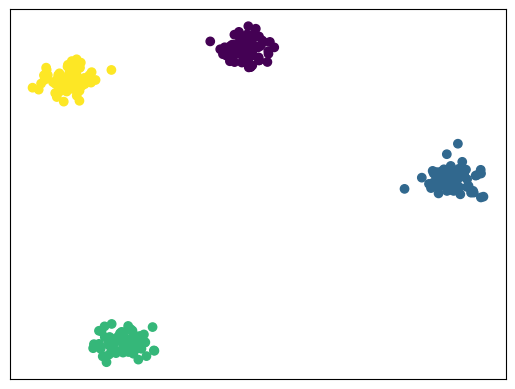

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ma

In [ ]:
X, y = datasets.make_blobs(n_samples=300, n_features=2, cluster_std=0.5, centers=4, random_state=42)
# X, y = datasets.make_moons(n_samples=200, noise=0.01, random_state=42)
plt.xticks([])
plt.yticks([])
plt.scatter(X[:, 0], X[:, 1], c=y)
# plt.savefig("tsne_n300_f2_c4_std05.eps", format="eps", bbox_inches='tight')
plt.show()

D = MinMaxScaler().fit_transform(pairwise_distances(X))

# Define the ranges for k and margin
k_values = [5, 10, 15, 20, 25]
margin_values = [1.0, 3.0, 5.0, 7.0, 9.0]

# Initialize empty lists to store the results for each metric
indices = {'ACC': [], 'NMI': [], 'ARI': [], 'SIL': []}

# Iterate through different k and margin values
for k in k_values:
    for margin in margin_values:
      # Reconstruct the similarity graph with current k
      S = kneighbors_graph(D, n_neighbors=k, mode='connectivity').toarray()
      S = torch.tensor(S, dtype=torch.float)

      # Run the experiment and collect the results
      acc, nmi, ari, sil, _, _ = train(S, y, 'cVAE', False, margin)
      indices['ACC'].append(acc)
      indices['NMI'].append(nmi)
      indices['ARI'].append(ari)
      indices['SIL'].append(sil)

# Params sensitivity

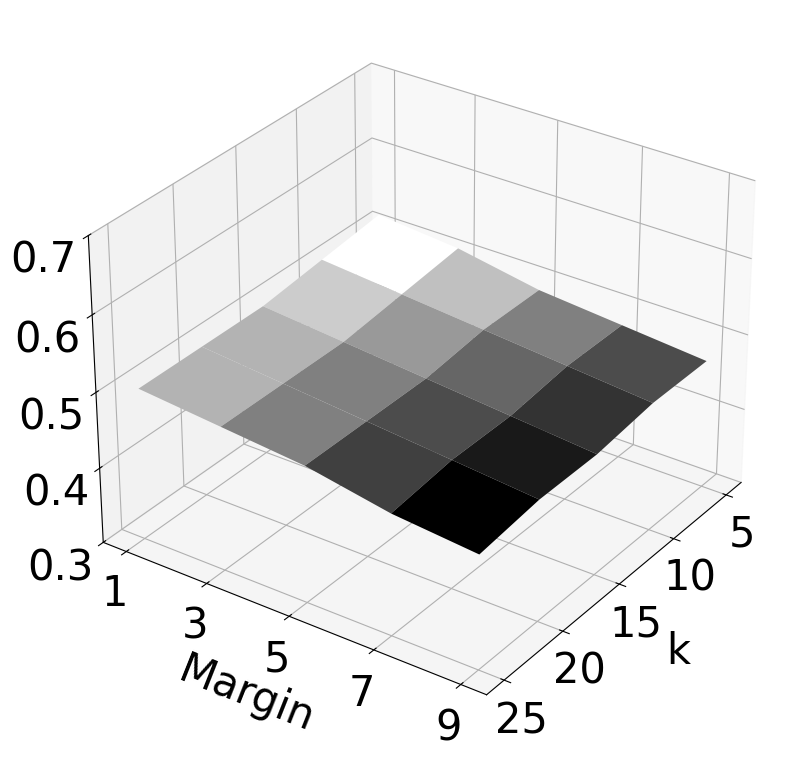

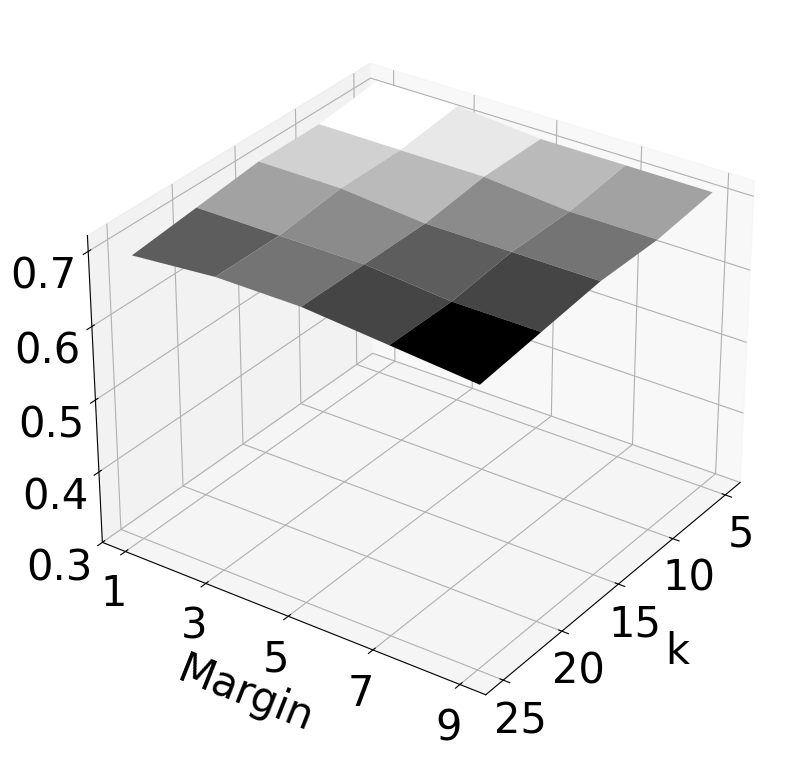

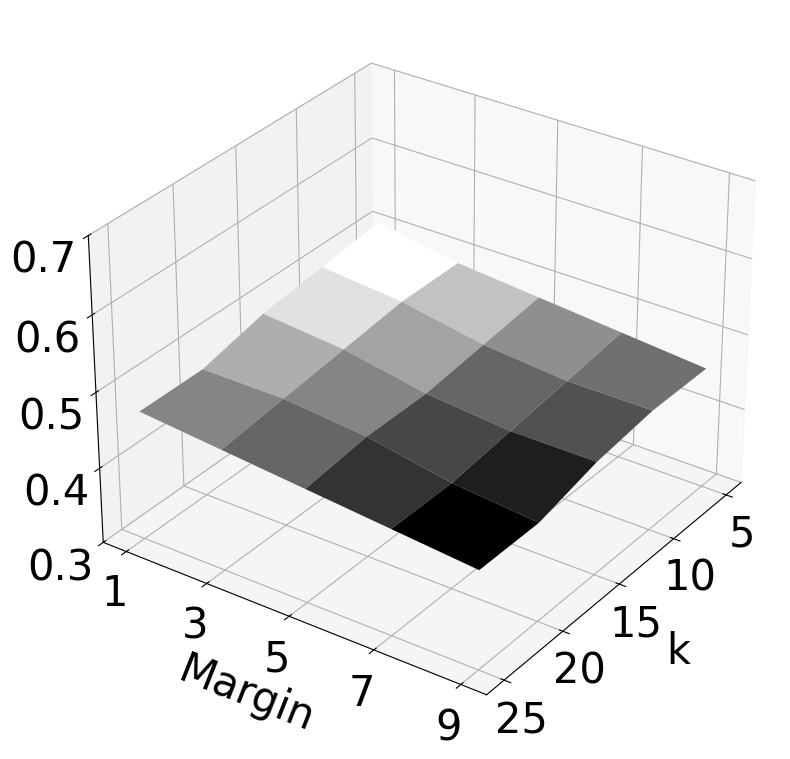

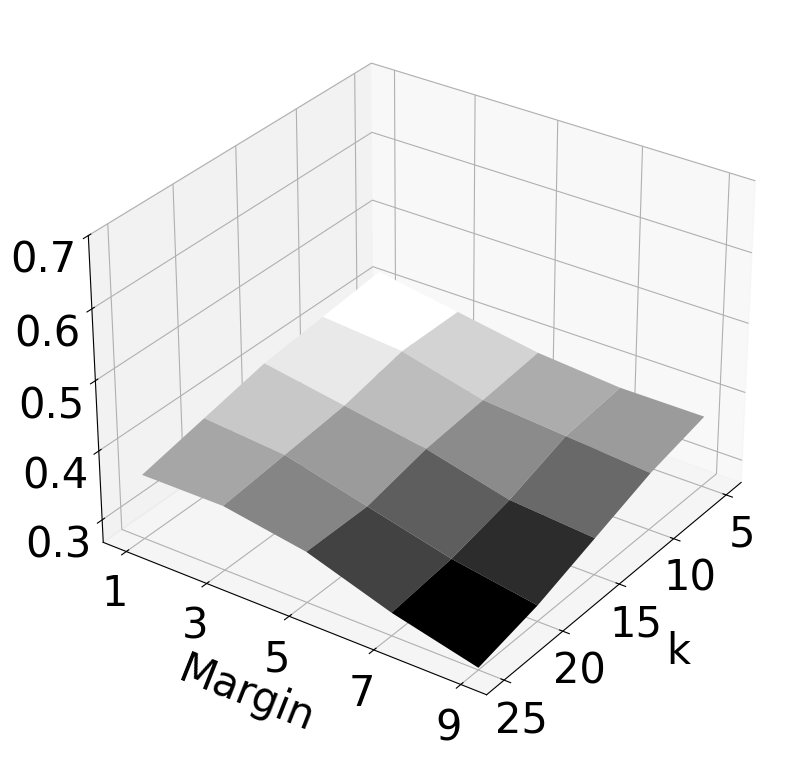

In [ ]:
# Create subplots for each metric
plt.rc('xtick', labelsize=30)
plt.rc('ytick', labelsize=30)
# plt.rc('ztick', labelsize=15)
plt.rc('axes', labelsize=30)
for i, indice in enumerate(indices):
  fig = plt.figure(figsize=(35, 15))
  ax = fig.add_subplot(2, 2, i + 1, projection='3d')

  # Create meshgrid for plotting
  K, M = np.meshgrid(k_values, margin_values)

  # Reshape the metric values for plotting
  metric_values = np.array(indices[indice]).reshape(len(k_values), len(margin_values))

  metric_values = rounding(metric_values)
  metric_values = np.round(metric_values, 2)

  # Creating color map
  hot_cmap = plt.get_cmap('grey')

  # Plot the 3D surface
  surf = ax.plot_surface(K, M, metric_values, cmap=hot_cmap)
  ax.set_xticks(k_values)
  ax.set_yticks(margin_values)
  ax.set_zticks([0.3, 0.4, 0.5, 0.6, 0.7])
  ax.tick_params(axis='z', which='major', pad=10)
  # ax.set_zticks([])
  ax.view_init(elev=30, azim=35)
  ax.set_xlabel('k', labelpad=20)
  ax.set_ylabel('Margin', labelpad=20)
  # ax.set_zlabel(indice)
  # ax.set_title(f'{indice} vs. k and Margin')

  # fig.colorbar(surf, ax = ax, shrink = 0.5, aspect = 5)
  plt.tight_layout()
  plt.savefig(f"{indice}_tsne_n300_f2_c4_std05.eps", format="eps", bbox_inches='tight')
  plt.show()

<ipython-input-29-a969c5d65cd3>:191: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


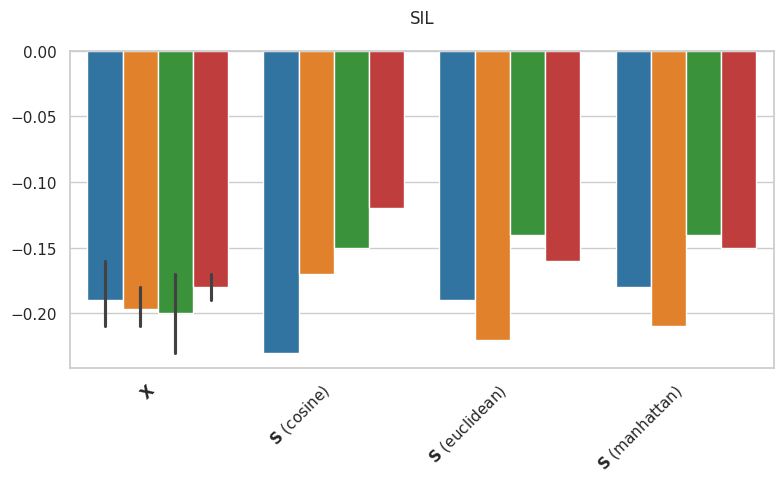

<ipython-input-29-a969c5d65cd3>:191: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


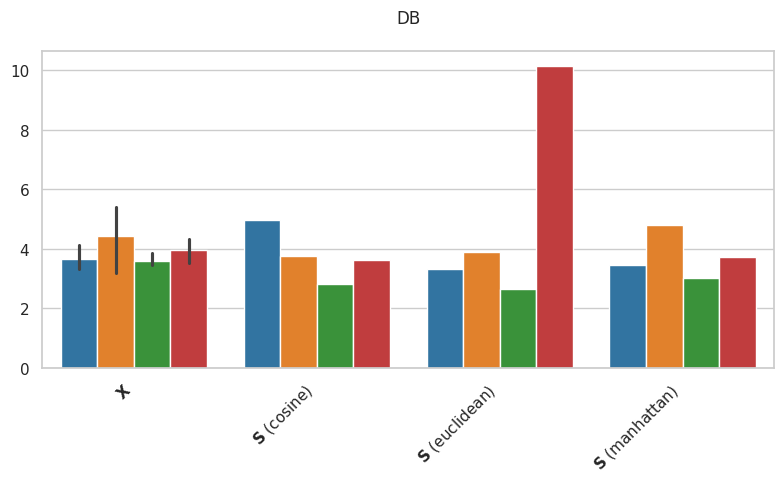

<ipython-input-29-a969c5d65cd3>:191: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


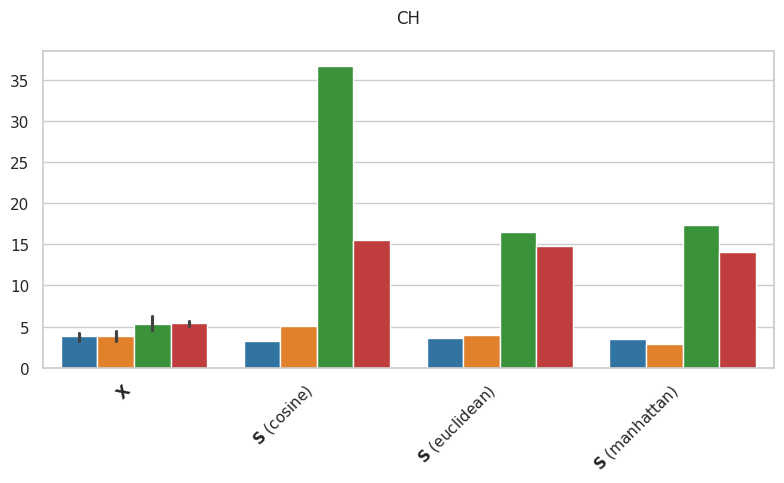

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample Size = 15
# data = [
#     # SIL
#     ("SIL", r"$\mathbf{S}$ (cosine)", "AE", -0.27),
#     ("SIL", r"$\mathbf{S}$ (cosine)", "cAE", -0.28),
#     ("SIL", r"$\mathbf{S}$ (cosine)", "VAE", -0.28),
#     ("SIL", r"$\mathbf{S}$ (cosine)", "cVAE", -0.28),
#     ("SIL", r"$\mathbf{X}$", "AE", -0.29),
#     ("SIL", r"$\mathbf{X}$", "cAE", -0.30),
#     ("SIL", r"$\mathbf{X}$", "VAE", -0.30),
#     ("SIL", r"$\mathbf{X}$", "cVAE", -0.32),
#     ("SIL", r"$\mathbf{S}$ (euclidean)", "AE", -0.29),
#     ("SIL", r"$\mathbf{S}$ (euclidean)", "cAE", -0.27),
#     ("SIL", r"$\mathbf{S}$ (euclidean)", "VAE", -0.28),
#     ("SIL", r"$\mathbf{S}$ (euclidean)", "cVAE", -0.26),
#     ("SIL", r"$\mathbf{S}$ (manhattan)", "AE", -0.30),
#     ("SIL", r"$\mathbf{S}$ (manhattan)", "cAE", -0.26),
#     ("SIL", r"$\mathbf{S}$ (manhattan)", "VAE", -0.30),
#     ("SIL", r"$\mathbf{S}$ (manhattan)", "cVAE", -0.25),

#     # DB
#     ("DB", r"$\mathbf{S}$ (cosine)", "AE", 3.40),
#     ("DB", r"$\mathbf{S}$ (cosine)", "cAE", 2.68),
#     ("DB", r"$\mathbf{S}$ (cosine)", "VAE", 2.98),
#     ("DB", r"$\mathbf{S}$ (cosine)", "cVAE", 3.09),
#     ("DB", r"$\mathbf{X}$", "AE", 3.11),
#     ("DB", r"$\mathbf{X}$", "cAE", 3.35),
#     ("DB", r"$\mathbf{X}$", "VAE", 3.03),
#     ("DB", r"$\mathbf{X}$", "cVAE", 3.65),
#     ("DB", r"$\mathbf{S}$ (euclidean)", "AE", 3.54),
#     ("DB", r"$\mathbf{S}$ (euclidean)", "cAE", 3.91),
#     ("DB", r"$\mathbf{S}$ (euclidean)", "VAE", 3.02),
#     ("DB", r"$\mathbf{S}$ (euclidean)", "cVAE", 3.11),
#     ("DB", r"$\mathbf{S}$ (manhattan)", "AE", 3.63),
#     ("DB", r"$\mathbf{S}$ (manhattan)", "cAE", 3.77),
#     ("DB", r"$\mathbf{S}$ (manhattan)", "VAE", 3.62),
#     ("DB", r"$\mathbf{S}$ (manhattan)", "cVAE", 3.12),

#     # CH
#     ("CH", r"$\mathbf{S}$ (cosine)", "AE", 1.39),
#     ("CH", r"$\mathbf{S}$ (cosine)", "cAE", 1.55),
#     ("CH", r"$\mathbf{S}$ (cosine)", "VAE", 1.26),
#     ("CH", r"$\mathbf{S}$ (cosine)", "cVAE", 1.35),
#     ("CH", r"$\mathbf{X}$", "AE", 1.58),
#     ("CH", r"$\mathbf{X}$", "cAE", 1.25),
#     ("CH", r"$\mathbf{X}$", "VAE", 1.33),
#     ("CH", r"$\mathbf{X}$", "cVAE", 1.22),
#     ("CH", r"$\mathbf{S}$ (euclidean)", "AE", 1.29),
#     ("CH", r"$\mathbf{S}$ (euclidean)", "cAE", 1.21),
#     ("CH", r"$\mathbf{S}$ (euclidean)", "VAE", 1.34),
#     ("CH", r"$\mathbf{S}$ (euclidean)", "cVAE", 1.61),
#     ("CH", r"$\mathbf{S}$ (manhattan)", "AE", 1.36),
#     ("CH", r"$\mathbf{S}$ (manhattan)", "cAE", 1.40),
#     ("CH", r"$\mathbf{S}$ (manhattan)", "VAE", 1.24),
#     ("CH", r"$\mathbf{S}$ (manhattan)", "cVAE", 2.02),
# ]

# sample size = 25
data = [
    # SIL - Checkmark (cosine)
    ("SIL", r"$\mathbf{S}$ (cosine)", "AE", -0.23),
    ("SIL", r"$\mathbf{S}$ (cosine)", "cAE", -0.17),
    ("SIL", r"$\mathbf{S}$ (cosine)", "VAE", -0.15),
    ("SIL", r"$\mathbf{S}$ (cosine)", "cVAE", -0.12),
    # SIL - X
    ("SIL", r"$\mathbf{X}$", "AE", -0.21),
    ("SIL", r"$\mathbf{X}$", "cAE", -0.20),
    ("SIL", r"$\mathbf{X}$", "VAE", -0.23),
    ("SIL", r"$\mathbf{X}$", "cVAE", -0.19),
    # SIL - Checkmark (euclidean)
    ("SIL", r"$\mathbf{S}$ (euclidean)", "AE", -0.19),
    ("SIL", r"$\mathbf{S}$ (euclidean)", "cAE", -0.22),
    ("SIL", r"$\mathbf{S}$ (euclidean)", "VAE", -0.14),
    ("SIL", r"$\mathbf{S}$ (euclidean)", "cVAE", -0.16),
    # SIL - X
    ("SIL", r"$\mathbf{X}$", "AE", -0.16),
    ("SIL", r"$\mathbf{X}$", "cAE", -0.18),
    ("SIL", r"$\mathbf{X}$", "VAE", -0.17),
    ("SIL", r"$\mathbf{X}$", "cVAE", -0.18),
    # SIL - Checkmark (manhattan)
    ("SIL", r"$\mathbf{S}$ (manhattan)", "AE", -0.18),
    ("SIL", r"$\mathbf{S}$ (manhattan)", "cAE", -0.21),
    ("SIL", r"$\mathbf{S}$ (manhattan)", "VAE", -0.14),
    ("SIL", r"$\mathbf{S}$ (manhattan)", "cVAE", -0.15),
    # SIL - X
    ("SIL", r"$\mathbf{X}$", "AE", -0.20),
    ("SIL", r"$\mathbf{X}$", "cAE", -0.21),
    ("SIL", r"$\mathbf{X}$", "VAE", -0.20),
    ("SIL", r"$\mathbf{X}$", "cVAE", -0.17),

    # DB - Checkmark (cosine)
    ("DB", r"$\mathbf{S}$ (cosine)", "AE", 4.96),
    ("DB", r"$\mathbf{S}$ (cosine)", "cAE", 3.76),
    ("DB", r"$\mathbf{S}$ (cosine)", "VAE", 2.81),
    ("DB", r"$\mathbf{S}$ (cosine)", "cVAE", 3.63),
    # DB - X
    ("DB", r"$\mathbf{X}$", "AE", 3.53),
    ("DB", r"$\mathbf{X}$", "cAE", 5.40),
    ("DB", r"$\mathbf{X}$", "VAE", 3.45),
    ("DB", r"$\mathbf{X}$", "cVAE", 3.51),
    # DB - Checkmark (euclidean)
    ("DB", r"$\mathbf{S}$ (euclidean)", "AE", 3.32),
    ("DB", r"$\mathbf{S}$ (euclidean)", "cAE", 3.90),
    ("DB", r"$\mathbf{S}$ (euclidean)", "VAE", 2.66),
    ("DB", r"$\mathbf{S}$ (euclidean)", "cVAE", 10.14),
    # DB - X
    ("DB", r"$\mathbf{X}$", "AE", 3.32),
    ("DB", r"$\mathbf{X}$", "cAE", 3.18),
    ("DB", r"$\mathbf{X}$", "VAE", 3.44),
    ("DB", r"$\mathbf{X}$", "cVAE", 3.74),
    # DB - Checkmark (manhattan)
    ("DB", r"$\mathbf{S}$ (manhattan)", "AE", 3.46),
    ("DB", r"$\mathbf{S}$ (manhattan)", "cAE", 4.78),
    ("DB", r"$\mathbf{S}$ (manhattan)", "VAE", 3.03),
    ("DB", r"$\mathbf{S}$ (manhattan)", "cVAE", 3.71),
    # DB - X
    ("DB", r"$\mathbf{X}$", "AE", 4.13),
    ("DB", r"$\mathbf{X}$", "cAE", 4.69),
    ("DB", r"$\mathbf{X}$", "VAE", 3.87),
    ("DB", r"$\mathbf{X}$", "cVAE", 4.64),

    # CH - Checkmark (cosine)
    ("CH", r"$\mathbf{S}$ (cosine)", "AE", 3.27),
    ("CH", r"$\mathbf{S}$ (cosine)", "cAE", 5.07),
    ("CH", r"$\mathbf{S}$ (cosine)", "VAE", 36.67),
    ("CH", r"$\mathbf{S}$ (cosine)", "cVAE", 15.52),
    # CH - X
    ("CH", r"$\mathbf{X}$", "AE", 4.16),
    ("CH", r"$\mathbf{X}$", "cAE", 4.02),
    ("CH", r"$\mathbf{X}$", "VAE", 4.60),
    ("CH", r"$\mathbf{X}$", "cVAE", 5.09),
    # CH - Checkmark (euclidean)
    ("CH", r"$\mathbf{S}$ (euclidean)", "AE", 3.58),
    ("CH", r"$\mathbf{S}$ (euclidean)", "cAE", 4.01),
    ("CH", r"$\mathbf{S}$ (euclidean)", "VAE", 16.46),
    ("CH", r"$\mathbf{S}$ (euclidean)", "cVAE", 14.74),
    # CH - X
    ("CH", r"$\mathbf{X}$", "AE", 4.15),
    ("CH", r"$\mathbf{X}$", "cAE", 4.50),
    ("CH", r"$\mathbf{X}$", "VAE", 4.90),
    ("CH", r"$\mathbf{X}$", "cVAE", 5.44),
    # CH - Checkmark (manhattan)
    ("CH", r"$\mathbf{S}$ (manhattan)", "AE", 3.44),
    ("CH", r"$\mathbf{S}$ (manhattan)", "cAE", 2.92),
    ("CH", r"$\mathbf{S}$ (manhattan)", "VAE", 17.38),
    ("CH", r"$\mathbf{S}$ (manhattan)", "cVAE", 14.03),
    # CH - X
    ("CH", r"$\mathbf{X}$", "AE", 3.25),
    ("CH", r"$\mathbf{X}$", "cAE", 3.20),
    ("CH", r"$\mathbf{X}$", "VAE", 6.29),
    ("CH", r"$\mathbf{X}$", "cVAE", 5.73),
]

df = pd.DataFrame(data, columns=["Metric", "Distance", "Model", "Value"])

# Define the display order and palette
distance_order = [r"$\mathbf{X}$",
                 r"$\mathbf{S}$ (cosine)",
                 r"$\mathbf{S}$ (euclidean)",
                 r"$\mathbf{S}$ (manhattan)"]
model_palette = {
    "AE": "#1f77b4",
    "cAE": "#ff7f0e",
    "VAE": "#2ca02c",
    "cVAE": "#d62728"
}

# Create separate figures for each metric
for metric in ["SIL", "DB", "CH"]:
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=df[df["Metric"] == metric],
        x="Distance", y="Value", hue="Model",
        hue_order=["AE", "cAE", "VAE", "cVAE"],
        order=distance_order,
        palette=model_palette
    )

    plt.title(metric, pad=20)
    plt.xlabel("")
    plt.ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.legend().remove()
    plt.tight_layout()
    plt.show()

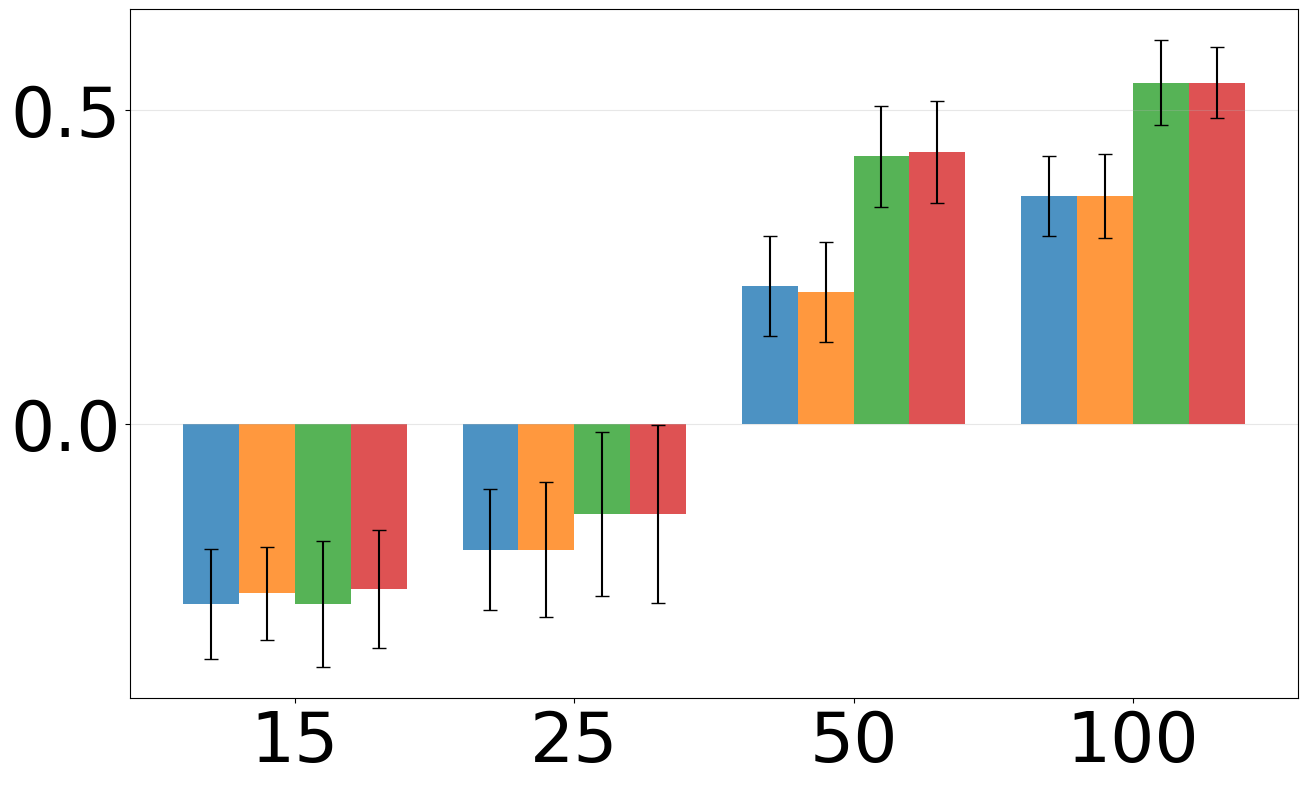

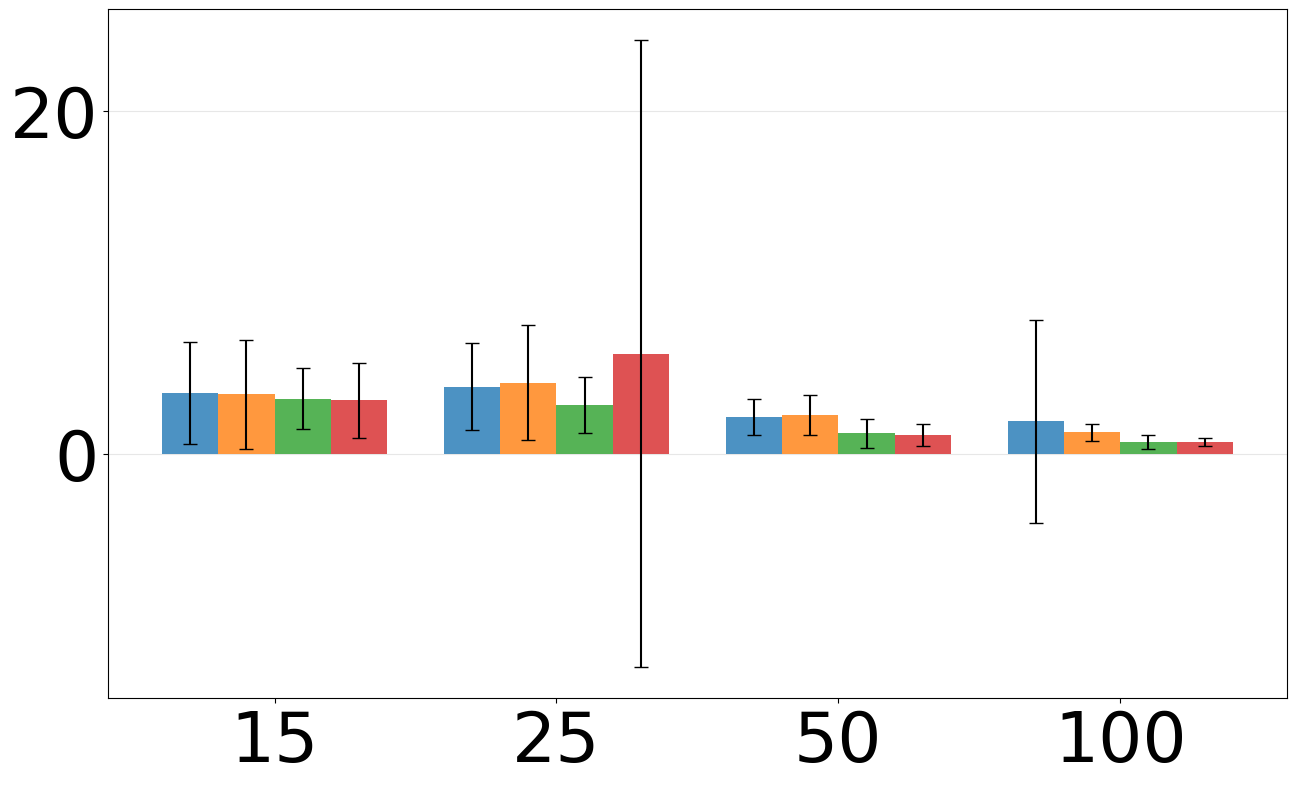

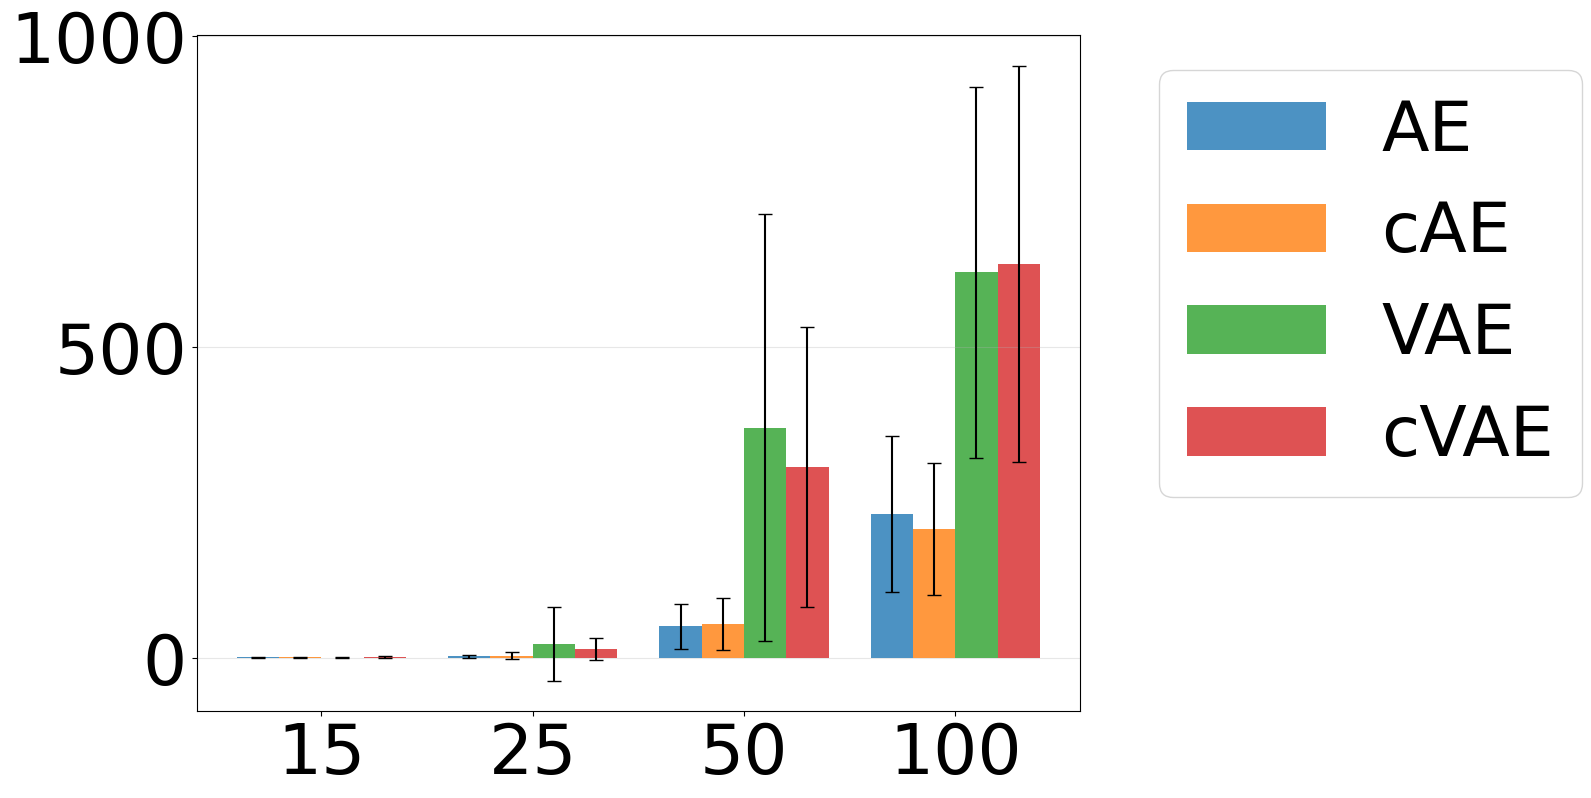

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data extracted from the LaTeX tables
metrics = ['SIL', 'DB', 'CH']
sample_sizes = [15, 25, 50, 100]
methods = ['AE', 'cAE', 'VAE', 'cVAE']
distance_metrics = ['×', 'cosine', 'euclidean', 'manhattan']

# Create a dictionary to store the data
data = {
    'SIL': {
        15: {
            '×': [-0.29, 0.11, -0.30, 0.09, -0.30, 0.11, -0.32, 0.12],
            'cosine': [-0.27, 0.09, -0.28, 0.07, -0.28, 0.10, -0.28, 0.08],
            'euclidean': [-0.29, 0.07, -0.27, 0.08, -0.28, 0.09, -0.26, 0.09],
            'manhattan': [-0.30, 0.10, -0.26, 0.07, -0.30, 0.11, -0.25, 0.11]
        },
        25: {
            '×': [-0.21, 0.09, -0.20, 0.10, -0.23, 0.11, -0.19, 0.12],
            'cosine': [-0.23, 0.10, -0.17, 0.12, -0.15, 0.14, -0.12, 0.16],
            'euclidean': [-0.19, 0.09, -0.22, 0.11, -0.14, 0.11, -0.16, 0.15],
            'manhattan': [-0.18, 0.10, -0.21, 0.09, -0.14, 0.14, -0.15, 0.11]
        },
        50: {
            '×': [0.23, 0.10, 0.25, 0.09, 0.40, 0.10, 0.37, 0.08],
            'cosine': [0.23, 0.08, 0.22, 0.09, 0.41, 0.07, 0.44, 0.09],
            'euclidean': [0.22, 0.08, 0.21, 0.09, 0.43, 0.08, 0.43, 0.09],
            'manhattan': [0.21, 0.08, 0.20, 0.05, 0.44, 0.09, 0.43, 0.06]
        },
        100: {
            '×': [0.27, 0.07, 0.27, 0.08, 0.41, 0.08, 0.44, 0.05],
            'cosine': [0.34, 0.07, 0.33, 0.07, 0.51, 0.08, 0.53, 0.06],
            'euclidean': [0.38, 0.06, 0.38, 0.07, 0.57, 0.06, 0.55, 0.06],
            'manhattan': [0.37, 0.06, 0.38, 0.06, 0.55, 0.06, 0.55, 0.05]
        }
    },
    'DB': {
        15: {
            '×': [3.11, 1.53, 3.35, 2.26, 3.03, 1.34, 3.65, 2.39],
            'cosine': [3.40, 3.84, 2.68, 1.43, 2.98, 1.25, 3.09, 2.70],
            'euclidean': [3.54, 2.34, 3.91, 3.51, 3.02, 1.88, 3.11, 1.89],
            'manhattan': [3.63, 2.46, 3.77, 3.96, 3.62, 2.11, 3.12, 1.91]
        },
        25: {
            '×': [3.53, 2.26, 5.40, 8.17, 3.45, 1.81, 3.51, 1.54],
            'cosine': [4.96, 3.87, 3.76, 3.44, 2.81, 1.46, 3.63, 2.51],
            'euclidean': [3.32, 1.06, 3.90, 2.23, 2.66, 1.41, 10.14, 31.44],
            'manhattan': [3.46, 1.78, 4.78, 4.10, 3.03, 1.93, 3.71, 2.68]
        },
        50: {
            '×': [2.36, 1.38, 1.71, 0.74, 1.22, 0.58, 1.09, 0.44],
            'cosine': [2.35, 1.08, 2.10, 1.06, 1.11, 0.71, 0.98, 0.51],
            'euclidean': [1.99, 1.14, 2.36, 1.41, 1.15, 0.75, 0.98, 0.55],
            'manhattan': [2.13, 0.91, 2.29, 0.94, 1.26, 0.98, 1.28, 0.79]
        },
        100: {
            '×': [2.05, 1.81, 2.20, 1.33, 1.02, 0.34, 1.08, 0.54],
            'cosine': [1.43, 0.82, 1.38, 0.55, 0.82, 0.68, 0.72, 0.35],
            'euclidean': [1.13, 0.52, 1.07, 0.42, 0.63, 0.22, 0.61, 0.14],
            'manhattan': [3.06, 10.18, 1.24, 0.54, 0.61, 0.11, 0.65, 0.18]
        }
    },
    'CH': {
        15: {
            '×': [1.58, 1.59, 1.25, 0.82, 1.33, 0.77, 1.22, 0.95],
            'cosine': [1.39, 0.81, 1.55, 0.98, 1.26, 0.83, 1.35, 0.82],
            'euclidean': [1.29, 0.67, 1.21, 0.65, 1.34, 0.75, 1.61, 0.89],
            'manhattan': [1.36, 1.75, 1.40, 1.04, 1.24, 0.93, 2.02, 2.37]
        },
        25: {
            '×': [4.16, 2.22, 4.02, 2.88, 4.60, 3.77, 5.09, 3.94],
            'cosine': [3.27, 2.15, 5.07, 8.08, 36.67, 98.59, 15.52, 21.25],
            'euclidean': [3.58, 2.02, 4.01, 4.45, 16.46, 16.35, 14.74, 19.69],
            'manhattan': [3.44, 2.25, 2.92, 1.67, 17.38, 22.92, 14.03, 11.38]
        },
        50: {
            '×': [39.8, 35.1, 39.5, 23.6, 172.2, 134.9, 146.4, 106.8],
            'cosine': [56.0, 38.3, 67.9, 53.8, 378.3, 332.8, 343.1, 206.1],
            'euclidean': [50.4, 29.2, 50.0, 38.4, 352.0, 297.3, 344.2, 264.4],
            'manhattan': [48.0, 40.6, 47.3, 30.4, 381.7, 392.9, 236.0, 199.0]
        },
        100: {
            '×': [86.3, 47.8, 88.4, 48.3, 295.1, 191.6, 321.6, 174.5],
            'cosine': [229.3, 109.8, 209.0, 127.7, 584.7, 316.5, 667.9, 318.5],
            'euclidean': [254.3, 152.3, 213.5, 95.6, 676.3, 326.7, 591.8, 306.9],
            'manhattan': [213.1, 108.8, 200.7, 90.9, 600.1, 243.6, 642.3, 330.1]
        }
    }
}

import numpy as np
import matplotlib.pyplot as plt

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Colors for methods
distance_metrics = ['cosine', 'euclidean', 'manhattan']  # Removed '×'

# Distance metric labels as requested
distance_labels = {
    'cosine': r"$\mathbf{S}$ (cosine)",
    'euclidean': r"$\mathbf{S}$ (euclidean)",
    'manhattan': r"$\mathbf{S}$ (manhattan)"
}

for i, metric in enumerate(metrics):
    # Create plots for each metric
    plt.figure(figsize=(25, 15))
    ax = plt.subplot(2, 2, i+1)

    # Set up bar positions
    bar_width = 0.2
    index = np.arange(len(sample_sizes))

    for j, method in enumerate(methods):
        means = []
        stds = []
        for size in sample_sizes:
            # Collect data for all distance metrics for this method
            method_data = []
            method_stds = []
            for dist_metric in distance_metrics:
                idx = methods.index(method) * 2
                method_data.append(data[metric][size][dist_metric][idx])
                method_stds.append(data[metric][size][dist_metric][idx+1])

            # Average across distance metrics
            means.append(np.mean(method_data))

            # Calculate combined std (sqrt of average of variances)
            variances = [std**2 for std in method_stds]
            stds.append(np.sqrt(np.mean(variances)))

        # Plot bars for this method
        bars = ax.bar(index + j*bar_width, means, bar_width,
                     color=colors[j],
                     label=method,
                     yerr=stds,
                     capsize=5,
                     alpha=0.8)

    ax.set_xticks(index + bar_width * 1.5)
    ax.set_xticklabels([str(s) for s in sample_sizes], fontsize=50)
    ax.tick_params(axis='y', labelsize=50)
    # ax.set_xlabel('Sample Size')
    # ax.set_ylabel(f'{metric} Score')
    # ax.set_title(f'{metric} Metric Comparison (with Distance Metrics)')
    ax.grid(True, which="both", ls="-", alpha=0.3, axis='y')

    # Only show legend on the last subplot
    if i == len(metrics)-1:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=50)

    plt.tight_layout()
    plt.savefig(f"ablation_{metric}_summary.eps", format="eps", bbox_inches='tight')
    plt.show()